# Faithfulness Evaluation

This notebook evaluates whether explanation-selected tokens causally affect the pairwise ranking decision of the cross-encoder reranker.

Explanations are evaluated with respect to the pairwise preference function `g(q, d_i, d_j) = s(q, d_i) - s(q, d_j)`.

This notebook reports 2 pertrubation tests (inspired by RankingSHAP paper):
- **Deletion / comprehensiveness:** mask the top-k most supportive tokens and measure how much the preference score drops.
- **Preservation / sufficiency:** keep only the top-k most supportive tokens and mask the remaining eligible tokens, then measure how well the preference signal is preserved.

Both tests are compared against random token selections and aggregated over queries with bootstrap confidence intervals.

In [18]:
# -- IMPORTS --
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sentence_transformers import CrossEncoder
from tqdm.auto import tqdm
from transformers import AutoTokenizer

In [19]:
model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
out_dir = Path("../outputs")

attr_path = out_dir / "attributions.pkl"
pair_paths = [out_dir / "pairwise_scores.parquet",
    out_dir / "pairwise_scores.pkl",
    out_dir / "pairwise_scores.csv"]

faithfulness_out = out_dir / "faithfulness_pairwise.csv"
faithfulness_summary_out = out_dir / "faithfulness_pairwise_summary.csv"

budgets = [1, 3, 5, 10, 20]
n_random_trials = 10
n_bootstrap = 1000
max_length = 512
seed = 42

rng = np.random.default_rng(seed)
torch.manual_seed(seed)

# Default to document tokens for cleaner pairwise deletion tests.
# Query tokens appear in both cross-encoder inputs; if token_scope="all", query
# perturbations should be interpreted carefully because the same query signal is duplicated.
token_scope = "doc"

# [MASK] keeps sequence length and positions fixed; "pad" removes masked tokens from attention.
mask_strategy = "mask"

In [20]:
ce_model = CrossEncoder(model_name, max_length=max_length)
bert_model = ce_model.model
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
bert_model = bert_model.to(device)
bert_model.eval()

if mask_strategy == "mask" and tokenizer.mask_token_id is None:
    raise ValueError("mask_strategy='mask' requires a tokenizer with a mask token.")
if tokenizer.pad_token_id is None:
    raise ValueError("Tokenizer must define a pad token.")

print(f"Model device: {device}")
print(f"Mask token: {tokenizer.mask_token} ({tokenizer.mask_token_id})")
print(f"Pad token: {tokenizer.pad_token} ({tokenizer.pad_token_id})")

Model device: mps
Mask token: [MASK] (103)
Pad token: [PAD] (0)


## Load Pairwise Instances and Attributions

The attribution file contains IG scores. The pairwise-score file contains the raw passages needed for perturbation and rescoring.


In [21]:
def load_pairs_table(paths):
    for path in paths:
        if not path.exists():
            continue
        if path.suffix == ".parquet":
            try:
                return pd.read_parquet(path)
            except ImportError:
                continue
        if path.suffix in {".pkl", ".pickle"}:
            return pd.read_pickle(path)
        if path.suffix == ".csv":
            return pd.read_csv(path)
    raise FileNotFoundError("No readable pairwise score file was found.")

def pair_key(qid, pid_i, pid_j):
    return (str(qid), str(pid_i), str(pid_j))

with open(attr_path, "rb") as f:
    attribution_records = pickle.load(f)

pairs_df = load_pairs_table(pair_paths)
pair_text_lookup = {
    pair_key(row.qid, row.pid_i, row.pid_j): {
        "passage_i": row.passage_i,
        "passage_j": row.passage_j,
        "score_i": float(row.score_i),
        "score_j": float(row.score_j),
        "g_score": float(row.g_score)} for row in pairs_df.itertuples(index=False)}

# Deletion is easiest to interpret when d_i is the model-preferred document.
records = [r for r in attribution_records if float(r["g_score"]) > 0]

print(f"Loaded attribution records: {len(attribution_records)}")
print(f"Loaded pairwise-score rows: {len(pairs_df)}")
print(f"Positive model-preference pairs used: {len(records)}")

if not records:
    raise ValueError("No records with g_score > 0 were found.")

Loaded attribution records: 90
Loaded pairwise-score rows: 90
Positive model-preference pairs used: 87


## Scoring and Masking Helpers

Perturbations are applied in tokenized input space. Special tokens are never masked. For preservation, non-selected eligible tokens are masked while selected tokens remain unchanged.


In [22]:
def tokenize_pair(query, passage):
    encoded = tokenizer(query, passage, max_length=max_length, truncation=True, padding=False, return_tensors="pt")

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    token_type_ids = encoded.get("token_type_ids")

    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(device)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    sep_positions = (input_ids[0] == tokenizer.sep_token_id).nonzero(as_tuple=True)[0].tolist()
    sep_idx = sep_positions[0] if sep_positions else len(tokens) - 1
    last_sep_idx = sep_positions[-1] if sep_positions else len(tokens) - 1

    query_positions = list(range(1, sep_idx))
    doc_positions = list(range(sep_idx + 1, last_sep_idx))
    eligible_positions = query_positions + doc_positions if token_scope == "all" else doc_positions

    tokenized = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "tokens": tokens,
        "sep_idx": sep_idx,
        "last_sep_idx": last_sep_idx,
        "query_positions": query_positions,
        "doc_positions": doc_positions,
        "eligible_positions": eligible_positions}
    
    return tokenized

def score_from_tokenized(tok):
    kwargs = {
        "input_ids": tok["input_ids"],
        "attention_mask": tok["attention_mask"]}
    
    if tok["token_type_ids"] is not None:
        kwargs["token_type_ids"] = tok["token_type_ids"]

    with torch.no_grad():
        outputs = bert_model(**kwargs)

    score = float(outputs.logits.squeeze(-1).detach().cpu().item())
    return score

def score_preference_from_text(query, passage_i, passage_j):
    tok_i = tokenize_pair(query, passage_i)
    tok_j = tokenize_pair(query, passage_j)
    score_preference = score_from_tokenized(tok_i) - score_from_tokenized(tok_j)
    
    return score_preference

def apply_mask(tok, positions_to_mask):
    perturbed = {
        "input_ids": tok["input_ids"].clone(),
        "attention_mask": tok["attention_mask"].clone(),
        "token_type_ids": None if tok["token_type_ids"] is None else tok["token_type_ids"].clone()}
    
    positions = sorted({int(p) for p in positions_to_mask if 0 <= int(p) < tok["input_ids"].shape[1]})
    if not positions:
        return perturbed

    if mask_strategy == "mask":
        perturbed["input_ids"][0, positions] = tokenizer.mask_token_id
    elif mask_strategy == "pad":
        perturbed["input_ids"][0, positions] = tokenizer.pad_token_id
        perturbed["attention_mask"][0, positions] = 0
    else:
        raise ValueError(f"Unsupported mask_strategy: {mask_strategy}")
    return perturbed

def perturb_pair_score(query, passage_i, passage_j, selected_i, selected_j, check):
    tok_i = tokenize_pair(query, passage_i)
    tok_j = tokenize_pair(query, passage_j)

    selected_i = set(int(p) for p in selected_i)
    selected_j = set(int(p) for p in selected_j)

    if check == "deletion":
        mask_i = selected_i
        mask_j = selected_j
    elif check == "preservation":
        mask_i = set(tok_i["eligible_positions"]) - selected_i
        mask_j = set(tok_j["eligible_positions"]) - selected_j
    else:
        raise ValueError(f"Unknown check: {check}")

    perturbed_i = apply_mask(tok_i, mask_i)
    perturbed_j = apply_mask(tok_j, mask_j)
    pertrubed_score = score_from_tokenized(perturbed_i) - score_from_tokenized(perturbed_j)
    
    return pertrubed_score

## Map Explanations to Pairwise-Support Tokens

For pairwise IG, support is read directly from the attribution to `g`. For pointwise IG, a pairwise proxy is constructed as `+IG(d_i)` and `-IG(d_j)`, because `g = s_i - s_j`. Positive support tokens are expected to increase `g`; masking them should therefore reduce the preference for `d_i`.


In [23]:
METHODS = {
    "pairwise_ig": "Pairwise IG",
    "pointwise_ig_proxy": "Pointwise IG proxy"}

def segment_positions_from_attr(attr):
    sep_idx = int(attr["sep_idx"])
    query_positions = list(range(1, sep_idx))
    doc_positions = list(range(sep_idx + 1, sep_idx + 1 + len(attr["doc_tokens"])))
    return query_positions, doc_positions

def support_rows_from_attr(attr, side, sign=1.0):
    query_positions, doc_positions = segment_positions_from_attr(attr)
    rows = []

    if token_scope == "all":
        for local_idx, position in enumerate(query_positions):
            rows.append({
                "side": side,
                "segment": "query",
                "position": int(position),
                "token": attr["query_tokens"][local_idx],
                "support_score": float(sign * attr["query_token_scores"][local_idx])})

    for local_idx, position in enumerate(doc_positions):
        rows.append({
            "side": side,
            "segment": "doc",
            "position": int(position),
            "token": attr["doc_tokens"][local_idx],
            "support_score": float(sign * attr["doc_token_scores"][local_idx])})
        
    return rows

def build_support_table(record, method):
    if method == "pairwise_ig":
        rows = []
        rows.extend(support_rows_from_attr(record["pairwise_ig"]["doc_i"], "doc_i", sign=1.0))
        rows.extend(support_rows_from_attr(record["pairwise_ig"]["doc_j"], "doc_j", sign=1.0))
    elif method == "pointwise_ig_proxy":
        rows = []
        rows.extend(support_rows_from_attr(record["pointwise_ig_i"], "doc_i", sign=1.0))
        rows.extend(support_rows_from_attr(record["pointwise_ig_j"], "doc_j", sign=-1.0))
    else:
        raise ValueError(f"Unknown method: {method}")

    table = pd.DataFrame(rows)
    if table.empty:
        return table
    
    support_values = table.sort_values("support_score", ascending=False).reset_index(drop=True)
    return support_values

def eligible_support_pool(record, method, positive_only=True):
    table = build_support_table(record, method)
    if table.empty:
        return table
    if positive_only:
        table = table[table["support_score"] > 0].copy()
    return table.reset_index(drop=True)

def select_explanation_tokens(record, method, k):
    table = eligible_support_pool(record, method, positive_only=True)
    return table.head(k).reset_index(drop=True)

def select_random_tokens(record, method, k, rng):
    # Draw from the same eligible pool as the explanation condition for this method.
    table = eligible_support_pool(record, method, positive_only=True)
    if table.empty:
        return table
    sample_size = min(k, len(table))
    return table.sample(n=sample_size, replace=False, random_state=int(rng.integers(0, 1_000_000_000))).reset_index(drop=True)

def selection_to_positions(selection):
    selected_i = selection.loc[selection["side"] == "doc_i", "position"].astype(int).tolist()
    selected_j = selection.loc[selection["side"] == "doc_j", "position"].astype(int).tolist()
    selected_i_j = selected_i, selected_j
    return selected_i_j

## Run Faithfulness Checks

For deletion, larger `delta_g = g - g'` and higher flip rate indicate more faithful explanations. For preservation, smaller absolute gap `|g - g'|` and higher sign preservation indicate that the selected tokens are sufficient to retain the decision.


In [25]:
faithfulness_rows = []
checks = ["deletion", "preservation"]

for record in tqdm(records, desc="Faithfulness evaluation"):
    original_g = float(record["g_score"])
    query = record["query"]
    text = pair_text_lookup[pair_key(record["qid"], record["pid_i"], record["pid_j"])]
    passage_i = text["passage_i"]
    passage_j = text["passage_j"]

    for method in METHODS:
        for k in budgets:
            selected = select_explanation_tokens(record, method, k)
            if selected.empty:
                continue
            actual_k = len(selected)
            selected_i, selected_j = selection_to_positions(selected)

            for check in checks:
                perturbed_g = perturb_pair_score(query, passage_i, passage_j, selected_i, selected_j, check=check)
                faithfulness_rows.append({
                    "qid": record["qid"],
                    "pid_i": record["pid_i"],
                    "pid_j": record["pid_j"],
                    "method": method,
                    "condition": "explanation",
                    "check": check,
                    "k": k,
                    "actual_k": actual_k,
                    "trial": 0,
                    "g": original_g,
                    "g_perturbed": perturbed_g,
                    "delta_g": original_g - perturbed_g,
                    "abs_g_gap": abs(original_g - perturbed_g),
                    "preference_flipped": int(np.sign(original_g) != np.sign(perturbed_g)),
                    "sign_preserved": int(np.sign(original_g) == np.sign(perturbed_g))})

                for trial in range(n_random_trials):
                    random_selection = select_random_tokens(record, method, actual_k, rng)
                    random_i, random_j = selection_to_positions(random_selection)
                    random_g = perturb_pair_score(query, passage_i, passage_j, random_i, random_j, check=check)
                    faithfulness_rows.append({
                        "qid": record["qid"],
                        "pid_i": record["pid_i"],
                        "pid_j": record["pid_j"],
                        "method": method,
                        "condition": "random",
                        "check": check,
                        "k": k,
                        "actual_k": len(random_selection),
                        "trial": trial,
                        "g": original_g,
                        "g_perturbed": random_g,
                        "delta_g": original_g - random_g,
                        "abs_g_gap": abs(original_g - random_g),
                        "preference_flipped": int(np.sign(original_g) != np.sign(random_g)),
                        "sign_preserved": int(np.sign(original_g) == np.sign(random_g))})

faithfulness_df = pd.DataFrame(faithfulness_rows)
print(f"Rows collected: {len(faithfulness_df)}")
faithfulness_df.head()

Faithfulness evaluation:   0%|          | 0/87 [00:00<?, ?it/s]

Rows collected: 19140


,qid,pid_i,pid_j,method,condition,check,k,actual_k,trial,g,g_perturbed,delta_g,abs_g_gap,preference_flipped,sign_preserved
0,1049774,7185662,6875160,pairwise_ig,explanation,deletion,1,1,0,18.357065,18.401919,-0.044854,0.044854,0,1
1,1049774,7185662,6875160,pairwise_ig,random,deletion,1,1,0,18.357065,17.361633,0.995432,0.995432,0,1
2,1049774,7185662,6875160,pairwise_ig,random,deletion,1,1,1,18.357065,17.957257,0.399808,0.399808,0,1
3,1049774,7185662,6875160,pairwise_ig,random,deletion,1,1,2,18.357065,17.691091,0.665975,0.665975,0,1
4,1049774,7185662,6875160,pairwise_ig,random,deletion,1,1,3,18.357065,18.153879,0.203186,0.203186,0,1


## Aggregate Over Queries

Results are first averaged per query, then bootstrapped over queries. This avoids giving queries with more sampled pairs disproportionate influence.


In [26]:
def bootstrap_mean_ci(values, rng, n_bootstrap=n_bootstrap, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        value = float(values[0])
        return value, value, value

    boot_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(float(np.mean(sample)))

    boostrap_mean_ci_result = (float(np.mean(values)), float(np.quantile(boot_means, alpha / 2)), float(np.quantile(boot_means, 1 - alpha / 2)))
    return boostrap_mean_ci_result


query_level = (
    faithfulness_df.groupby(["method", "condition", "check", "k", "qid"], as_index=False).agg(
        mean_delta_g=("delta_g", "mean"),
        mean_abs_g_gap=("abs_g_gap", "mean"),
        flip_rate=("preference_flipped", "mean"),
        sign_preservation_rate=("sign_preserved", "mean"),
        mean_actual_k=("actual_k", "mean")))

summary_rows = []
summary_rng = np.random.default_rng(seed)

for (method, condition, check, k), group in query_level.groupby(["method", "condition", "check", "k"]):
    delta_mean, delta_low, delta_high = bootstrap_mean_ci(group["mean_delta_g"].to_numpy(), summary_rng)
    gap_mean, gap_low, gap_high = bootstrap_mean_ci(group["mean_abs_g_gap"].to_numpy(), summary_rng)
    flip_mean, flip_low, flip_high = bootstrap_mean_ci(group["flip_rate"].to_numpy(), summary_rng)
    preserve_mean, preserve_low, preserve_high = bootstrap_mean_ci(group["sign_preservation_rate"].to_numpy(), summary_rng)

    summary_rows.append({
        "method": method,
        "condition": condition,
        "check": check,
        "k": k,
        "n_queries": group["qid"].nunique(),
        "mean_actual_k": float(group["mean_actual_k"].mean()),
        "mean_delta_g": delta_mean,
        "delta_g_ci_low": delta_low,
        "delta_g_ci_high": delta_high,
        "mean_abs_g_gap": gap_mean,
        "abs_g_gap_ci_low": gap_low,
        "abs_g_gap_ci_high": gap_high,
        "flip_rate": flip_mean,
        "flip_rate_ci_low": flip_low,
        "flip_rate_ci_high": flip_high,
        "sign_preservation_rate": preserve_mean,
        "sign_preservation_ci_low": preserve_low,
        "sign_preservation_ci_high": preserve_high})

summary_df = pd.DataFrame(summary_rows).sort_values(["check", "method", "condition", "k"]).reset_index(drop=True)
summary_df.head(20)

,method,condition,check,k,n_queries,mean_actual_k,mean_delta_g,delta_g_ci_low,delta_g_ci_high,mean_abs_g_gap,abs_g_gap_ci_low,abs_g_gap_ci_high,flip_rate,flip_rate_ci_low,flip_rate_ci_high,sign_preservation_rate,sign_preservation_ci_low,sign_preservation_ci_high
0,pairwise_ig,explanation,deletion,1,18,1.0,1.475075,0.930424,2.023892,1.489785,0.943071,2.061232,0.086111,0.022222,0.161181,0.913889,0.838889,0.975000
1,pairwise_ig,explanation,deletion,3,18,3.0,9.753925,6.657947,13.197005,9.783256,6.558763,13.164018,0.394444,0.211042,0.594583,0.605556,0.416667,0.783403
2,pairwise_ig,explanation,deletion,5,18,5.0,12.079592,8.452552,15.513421,12.094429,8.536371,15.236342,0.538889,0.333333,0.727917,0.461111,0.274792,0.666736
3,pairwise_ig,explanation,deletion,10,18,10.0,14.773440,11.368137,17.833563,14.787148,11.230815,17.957680,0.658333,0.488889,0.833333,0.341667,0.166667,0.508333
4,pairwise_ig,explanation,deletion,20,18,20.0,17.973299,15.162994,20.505018,17.973299,15.045618,20.267409,0.805556,0.633333,0.950000,0.194444,0.055556,0.361111
5,pairwise_ig,random,deletion,1,18,1.0,0.211995,0.146484,0.287848,0.262312,0.194034,0.335685,0.004722,0.000000,0.010556,0.995278,0.989444,1.000000
6,pairwise_ig,random,deletion,3,18,3.0,0.634720,0.430254,0.910559,0.694373,0.495144,0.991535,0.043611,0.016653,0.075278,0.956389,0.923042,0.983056
7,pairwise_ig,random,deletion,5,18,5.0,1.141794,0.810138,1.521231,1.200559,0.851666,1.607749,0.072500,0.021938,0.126389,0.927500,0.871944,0.976674
8,pairwise_ig,random,deletion,10,18,10.0,2.510328,1.809347,3.261860,2.549684,1.847165,3.337160,0.126667,0.053868,0.213625,0.873333,0.790535,0.946674
9,pairwise_ig,random,deletion,20,18,20.0,6.273507,4.675325,7.947124,6.296149,4.671578,8.034740,0.300833,0.162771,0.435861,0.699167,0.566042,0.819743


## Main Result Tables

For deletion, focus on `mean_delta_g` and `flip_rate`. For preservation, focus on `mean_abs_g_gap` and `sign_preservation_rate`.


In [27]:
deletion_table = summary_df[summary_df["check"] == "deletion"][[
    "method", "condition", "k", "mean_delta_g", "delta_g_ci_low", "delta_g_ci_high", "flip_rate", "flip_rate_ci_low", "flip_rate_ci_high"]]

preservation_table = summary_df[summary_df["check"] == "preservation"][[
    "method", "condition", "k", "mean_abs_g_gap", "abs_g_gap_ci_low", "abs_g_gap_ci_high", "sign_preservation_rate", "sign_preservation_ci_low", "sign_preservation_ci_high"]]

display(deletion_table)
display(preservation_table)

,method,condition,k,mean_delta_g,delta_g_ci_low,delta_g_ci_high,flip_rate,flip_rate_ci_low,flip_rate_ci_high
0,pairwise_ig,explanation,1,1.475075,0.930424,2.023892,0.086111,0.022222,0.161181
1,pairwise_ig,explanation,3,9.753925,6.657947,13.197005,0.394444,0.211042,0.594583
2,pairwise_ig,explanation,5,12.079592,8.452552,15.513421,0.538889,0.333333,0.727917
3,pairwise_ig,explanation,10,14.773440,11.368137,17.833563,0.658333,0.488889,0.833333
4,pairwise_ig,explanation,20,17.973299,15.162994,20.505018,0.805556,0.633333,0.950000
5,pairwise_ig,random,1,0.211995,0.146484,0.287848,0.004722,0.000000,0.010556
6,pairwise_ig,random,3,0.634720,0.430254,0.910559,0.043611,0.016653,0.075278
7,pairwise_ig,random,5,1.141794,0.810138,1.521231,0.072500,0.021938,0.126389
8,pairwise_ig,random,10,2.510328,1.809347,3.261860,0.126667,0.053868,0.213625
9,pairwise_ig,random,20,6.273507,4.675325,7.947124,0.300833,0.162771,0.435861


,method,condition,k,mean_abs_g_gap,abs_g_gap_ci_low,abs_g_gap_ci_high,sign_preservation_rate,sign_preservation_ci_low,sign_preservation_ci_high
20,pairwise_ig,explanation,1,10.252219,7.902134,12.721968,0.663889,0.477778,0.827847
21,pairwise_ig,explanation,3,8.455908,6.541619,10.529801,0.952778,0.872222,1.000000
22,pairwise_ig,explanation,5,8.115735,6.050113,10.297692,0.977778,0.933333,1.000000
23,pairwise_ig,explanation,10,9.099699,6.596700,11.380276,1.000000,1.000000,1.000000
24,pairwise_ig,explanation,20,9.548916,7.220409,11.883460,1.000000,1.000000,1.000000
25,pairwise_ig,random,1,10.801038,8.368969,13.540256,0.399444,0.253021,0.549201
26,pairwise_ig,random,3,10.777708,8.198770,13.208499,0.446111,0.321111,0.574458
27,pairwise_ig,random,5,10.556364,7.998244,13.312210,0.501667,0.378861,0.631708
28,pairwise_ig,random,10,10.450634,7.972649,13.020836,0.611111,0.507215,0.709451
29,pairwise_ig,random,20,9.711050,7.648846,12.108001,0.802500,0.742222,0.854444


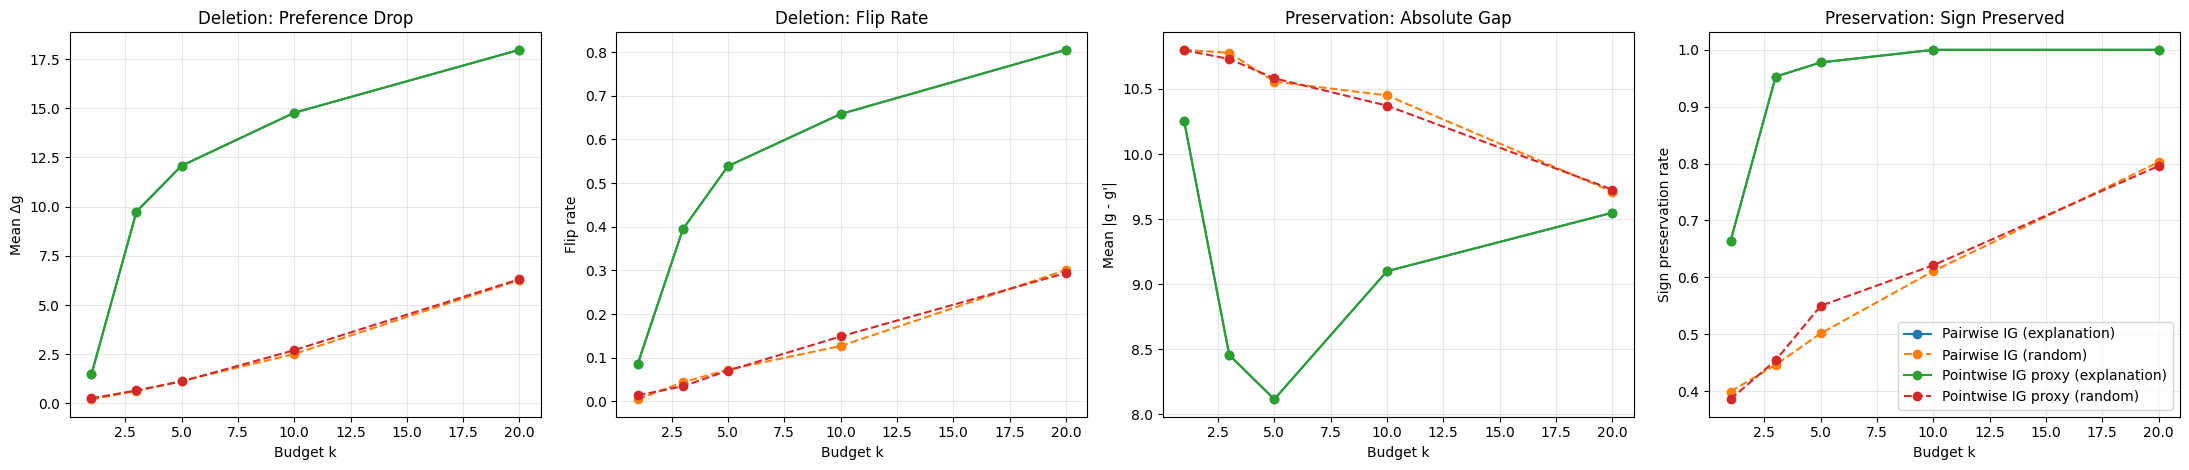

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), sharex=True)
line_styles = {"explanation": "-", "random": "--"}

for method, label in METHODS.items():
    for condition in ["explanation", "random"]:
        subset = summary_df[(summary_df["method"] == method) & (summary_df["condition"] == condition)]
        deletion = subset[subset["check"] == "deletion"].sort_values("k")
        preservation = subset[subset["check"] == "preservation"].sort_values("k")

        axes[0].plot(deletion["k"], deletion["mean_delta_g"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[1].plot(deletion["k"], deletion["flip_rate"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[2].plot(preservation["k"], preservation["mean_abs_g_gap"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")
        axes[3].plot(preservation["k"], preservation["sign_preservation_rate"], marker="o", linestyle=line_styles[condition], label=f"{label} ({condition})")

axes[0].set_title("Deletion: Preference Drop")
axes[0].set_ylabel("Mean Δg")
axes[1].set_title("Deletion: Flip Rate")
axes[1].set_ylabel("Flip rate")
axes[2].set_title("Preservation: Absolute Gap")
axes[2].set_ylabel("Mean |g - g'|")
axes[3].set_title("Preservation: Sign Preserved")
axes[3].set_ylabel("Sign preservation rate")

for ax in axes:
    ax.set_xlabel("Budget k")
    ax.grid(alpha=0.3)

axes[-1].legend(loc="best")
plt.tight_layout()
plt.show()

## Qualitative Inspection

Inspect a high-impact example to ensure the selected tokens are interpretable and the perturbation effect is plausible.


In [29]:
def show_selected_tokens(record, method, k=10):
    selection = select_explanation_tokens(record, method, k)
    print(f"Method: {method}")
    print(f"Query: {record['query']}")
    print(f"Original g: {float(record['g_score']):.4f}")
    display(selection[["side", "segment", "position", "token", "support_score"]])

example_row = (
    faithfulness_df[
        (faithfulness_df["method"] == "pairwise_ig")
        & (faithfulness_df["condition"] == "explanation")
        & (faithfulness_df["check"] == "deletion")
        & (faithfulness_df["k"] == min(10, max(budgets)))].sort_values("delta_g", ascending=False).iloc[0])

example_record = next(
    r for r in records
    if str(r["qid"]) == str(example_row["qid"])
    and str(r["pid_i"]) == str(example_row["pid_i"])
    and str(r["pid_j"]) == str(example_row["pid_j"]))

print(example_row[["qid", "pid_i", "pid_j", "g", "g_perturbed", "delta_g", "preference_flipped"]])
show_selected_tokens(example_record, "pairwise_ig", k=int(example_row["k"]))

qid                      437291
pid_i                   7679571
pid_j                   7765083
g                      15.63728
g_perturbed           -9.155843
delta_g               24.793123
preference_flipped            1
Name: 15466, dtype: object
Method: pairwise_ig
Query: largest shipping day of year
Original g: 15.6373


,side,segment,position,token,support_score
0,doc_i,doc,17,year,1.484634
1,doc_i,doc,12,biggest,1.458943
2,doc_i,doc,14,day,1.372899
3,doc_i,doc,13,shipping,1.193599
4,doc_j,doc,13,##ps,0.944632
5,doc_j,doc,11,box,0.712789
6,doc_i,doc,9,monday,0.569933
7,doc_j,doc,27,weight,0.489340
8,doc_i,doc,31,gigantic,0.448341
9,doc_i,doc,19,amazon,0.435161


## Diagnose Negative Low-k Deletion Cases

If deletion of supposedly supportive tokens increases `g` instead of decreasing it, inspect these cases manually. This usually reveals whether the selected token is on `d_i` or `d_j`, whether it is a query/document token, or whether masking creates an artifact.


In [30]:
negative_low_k = (
    faithfulness_df[
        (faithfulness_df["method"] == "pairwise_ig")
        & (faithfulness_df["condition"] == "explanation")
        & (faithfulness_df["check"] == "deletion")
        & (faithfulness_df["k"].isin([1, 3]))
        & (faithfulness_df["delta_g"] < 0)
    ]
    .sort_values("delta_g")
    .head(5)
)

print(f"Negative low-k deletion cases found: {len(negative_low_k)}")
display(negative_low_k[["qid", "pid_i", "pid_j", "k", "g", "g_perturbed", "delta_g", "preference_flipped"]])

for _, row in negative_low_k.iterrows():
    record = next(
        r for r in records
        if str(r["qid"]) == str(row["qid"])
        and str(r["pid_i"]) == str(row["pid_i"])
        and str(r["pid_j"]) == str(row["pid_j"])
    )
    selected = select_explanation_tokens(record, "pairwise_ig", int(row["k"]))
    print("\n" + "=" * 80)
    print(f"qid={row['qid']} pid_i={row['pid_i']} pid_j={row['pid_j']} k={row['k']}")
    print(f"g={row['g']:.4f}, g_perturbed={row['g_perturbed']:.4f}, delta_g={row['delta_g']:.4f}")
    print(f"Query: {record['query']}")
    display(selected[["side", "segment", "position", "token", "support_score"]])


Negative low-k deletion cases found: 3


,qid,pid_i,pid_j,k,g,g_perturbed,delta_g,preference_flipped
14762,264410,7367042,428612,3,15.378033,16.697941,-1.319908,0
14740,264410,7367042,428612,1,15.378033,15.995128,-0.617095,0
0,1049774,7185662,6875160,1,18.357065,18.401919,-0.044854,0



qid=264410 pid_i=7367042 pid_j=428612 k=3
g=15.3780, g_perturbed=16.6979, delta_g=-1.3199
Query: how long is recovery from hemorrhoid banding


,side,segment,position,token,support_score
0,doc_j,doc,15,heal,0.885090
1,doc_j,doc,33,heal,0.613697
2,doc_i,doc,29,weeks,0.518564



qid=264410 pid_i=7367042 pid_j=428612 k=1
g=15.3780, g_perturbed=15.9951, delta_g=-0.6171
Query: how long is recovery from hemorrhoid banding


,side,segment,position,token,support_score
0,doc_j,doc,15,heal,0.88509



qid=1049774 pid_i=7185662 pid_j=6875160 k=1
g=18.3571, g_perturbed=18.4019, delta_g=-0.0449
Query: cost of attendance eastern illinois university


,side,segment,position,token,support_score
0,doc_j,doc,10,schooling,1.121461


## Save Results


In [31]:
faithfulness_df.to_csv(faithfulness_out, index=False)
summary_df.to_csv(faithfulness_summary_out, index=False)

print(f"Saved detailed faithfulness results to {faithfulness_out}")
print(f"Saved summary faithfulness results to {faithfulness_summary_out}")

Saved detailed faithfulness results to ../outputs/faithfulness_pairwise.csv
Saved summary faithfulness results to ../outputs/faithfulness_pairwise_summary.csv
